In [2]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..'))
from utils import get_spike_activity, sdf, sdf_mean
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
rooth_path = "/home/csartor1/code/NODS/results/"
with open("/home/csartor1/code/NODS/network_configuration.json", "r") as json_file:
    net_config = json.load(json_file)

CS_burst_dur = net_config["devices"]["CS"]["parameters"]["burst_dur"]
CS_start_first = float(net_config["devices"]["CS"]["parameters"]["start_first"])
between_start = net_config["devices"]["CS"]["parameters"]["between_start"]
n_trials = net_config["devices"]["CS"]["parameters"]["n_trials"]
US_start_first = float(net_config["devices"]["US"]["parameters"]["start_first"])

cell_color = net_config["cell_types"]["purkinje_cell"]["color"][0]
CS_color = net_config["colors"]["CS"]
US_color = net_config["colors"]["US"]
with_NO_color = net_config["devices"]["nNOS"]["color"][0]
without_NO_color = "#000000"

In [4]:
palette = list(reversed(sns.color_palette("viridis", n_trials).as_hex()))
sm = plt.cm.ScalarMappable(cmap="viridis_r", norm=plt.Normalize(vmin=0, vmax=n_trials))

In [ ]:
cell = "pc_spikes"
result_path = rooth_path+"wo_NO/4Hz/"

sdf_mean_trials_simulations = []
sdf_mean_cell = []
for k in range(5):
    file_path = result_path+ f"sim_{k+1}/"
    print(f"sim_{k+1}", flush=True)
    sdf_mean_over_trials = []
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0]
    intervals = [(500,1000), (14500,15000)]

    for start, end in intervals:
        mask = (times >= start) & (times <= end)
        filtered_times = times[mask]
        filtered_ids = ID_cell[mask]

    # Convert results back to numpy arrays for consistency
        filtered_times = np.array(filtered_times)
        filtered_ids = np.array(filtered_ids)

        plt.figure()
        plt.axvline(CS_start_first+start, label="CS start", linewidth=3, c=CS_color)
        plt.axvline(US_start_first - between_start + start, label="US start", linewidth=3, c=US_color)
        plt.axvline(CS_start_first + CS_burst_dur + start, label="CS & US end ", linewidth=3, c="#E1D5E7")
        plt.scatter(filtered_times,filtered_ids, s = 1)
        plt.title(f"standard STDP trial {int(end/500)}")
        plt.ylabel("SDF [Hz]")
        plt.xlabel("Time [ms]")
        plt.legend()
        plt.show()


In [ ]:
cell = "pc_spikes"
result_path = rooth_path+"test/thr_60/"

sdf_mean_trials_simulations = []
sdf_mean_cell = []
for k in range(5):
    file_path = result_path+ f"sim_{k+1}/"
    print(f"sim_{k+1}", flush=True)
    sdf_mean_over_trials = []
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0]
    intervals = [(500,1000), (14500,15000)]

    for start, end in intervals:
        mask = (times >= start) & (times <= end)
        filtered_times = times[mask]
        filtered_ids = ID_cell[mask]

    # Convert results back to numpy arrays for consistency
        filtered_times = np.array(filtered_times)
        filtered_ids = np.array(filtered_ids)

        plt.figure()
        plt.axvline(CS_start_first+start, label="CS start", linewidth=3, c=CS_color)
        plt.axvline(US_start_first - between_start + start, label="US start", linewidth=3, c=US_color)
        plt.axvline(CS_start_first + CS_burst_dur + start, label="CS & US end ", linewidth=3, c="#E1D5E7")
        plt.scatter(filtered_times,filtered_ids, s = 1)
        plt.title(f"NO-Dependent STDP trial {int(end/500)} thr: 60")
        plt.ylabel("SDF [Hz]")
        plt.xlabel("Time [ms]")
        plt.legend()
        plt.show()

In [ ]:
cell = "pc_spikes"
result_path = rooth_path+"test/thr_100/"

sdf_mean_trials_simulations = []
sdf_mean_cell = []
for k in range(5):
    file_path = result_path+ f"sim_{k+1}/"
    print(f"sim_{k+1}", flush=True)
    sdf_mean_over_trials = []
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0]
    intervals = [(500,1000), (14500,15000)]

    for start, end in intervals:
        mask = (times >= start) & (times <= end)
        filtered_times = times[mask]
        filtered_ids = ID_cell[mask]

    # Convert results back to numpy arrays for consistency
        filtered_times = np.array(filtered_times)
        filtered_ids = np.array(filtered_ids)

        plt.figure()
        plt.axvline(CS_start_first+start, label="CS start", linewidth=3, c=CS_color)
        plt.axvline(US_start_first - between_start + start, label="US start", linewidth=3, c=US_color)
        plt.axvline(CS_start_first + CS_burst_dur + start, label="CS & US end ", linewidth=3, c="#E1D5E7")
        plt.scatter(filtered_times,filtered_ids, s = 1)
        plt.title(f"NO-Dependent STDP trial {int(end/500)} thr: 100")
        plt.ylabel("SDF [Hz]")
        plt.xlabel("Time [ms]")
        plt.legend()
        plt.show()

In [5]:
# heatmaps of number of spikes for every PC
cell = 'pc_spikes'
time_bin = 50
trial_len = between_start
n_sim = 5
pc_ids = np.arange(71,170)

In [6]:
result_path = rooth_path+"wo_NO/4Hz/"
pc_spikes_matrix_trial_2 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
pc_spikes_matrix_trial_30 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
pc_spikes_matrix_trial_diff = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
trial_len = between_start
for k in range(0,n_sim):
    file_path = result_path+f'sim_{k+1}/'
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0].astype(int)

    intervals = [(500,1000), (14500,15000)]
    for i,interval in enumerate(intervals):
        for j,t_interval in enumerate(range(interval[0],interval[1],time_bin)):
            start = t_interval
            end = t_interval+time_bin
            mask = (times >= start) & (times <= end)
            filtered_ids = ID_cell[mask]


            for id in np.unique(filtered_ids):
                count_spikes = len(np.where(filtered_ids==id)[0])
                ind_pc_id = np.where(pc_ids == id)[0]
                if i == 0:
                    pc_spikes_matrix_trial_2[ind_pc_id,j,k] = count_spikes
                else:
                    pc_spikes_matrix_trial_30[ind_pc_id,j,k] = count_spikes

pc_spikes_matrix_trial_30 = np.median(pc_spikes_matrix_trial_30,axis = 2)
pc_spikes_matrix_trial_2 = np.median(pc_spikes_matrix_trial_2,axis = 2)
pc_spikes_matrix_trial_diff = pc_spikes_matrix_trial_30 - pc_spikes_matrix_trial_2

/tmp/ipykernel_3039473/2442724567.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


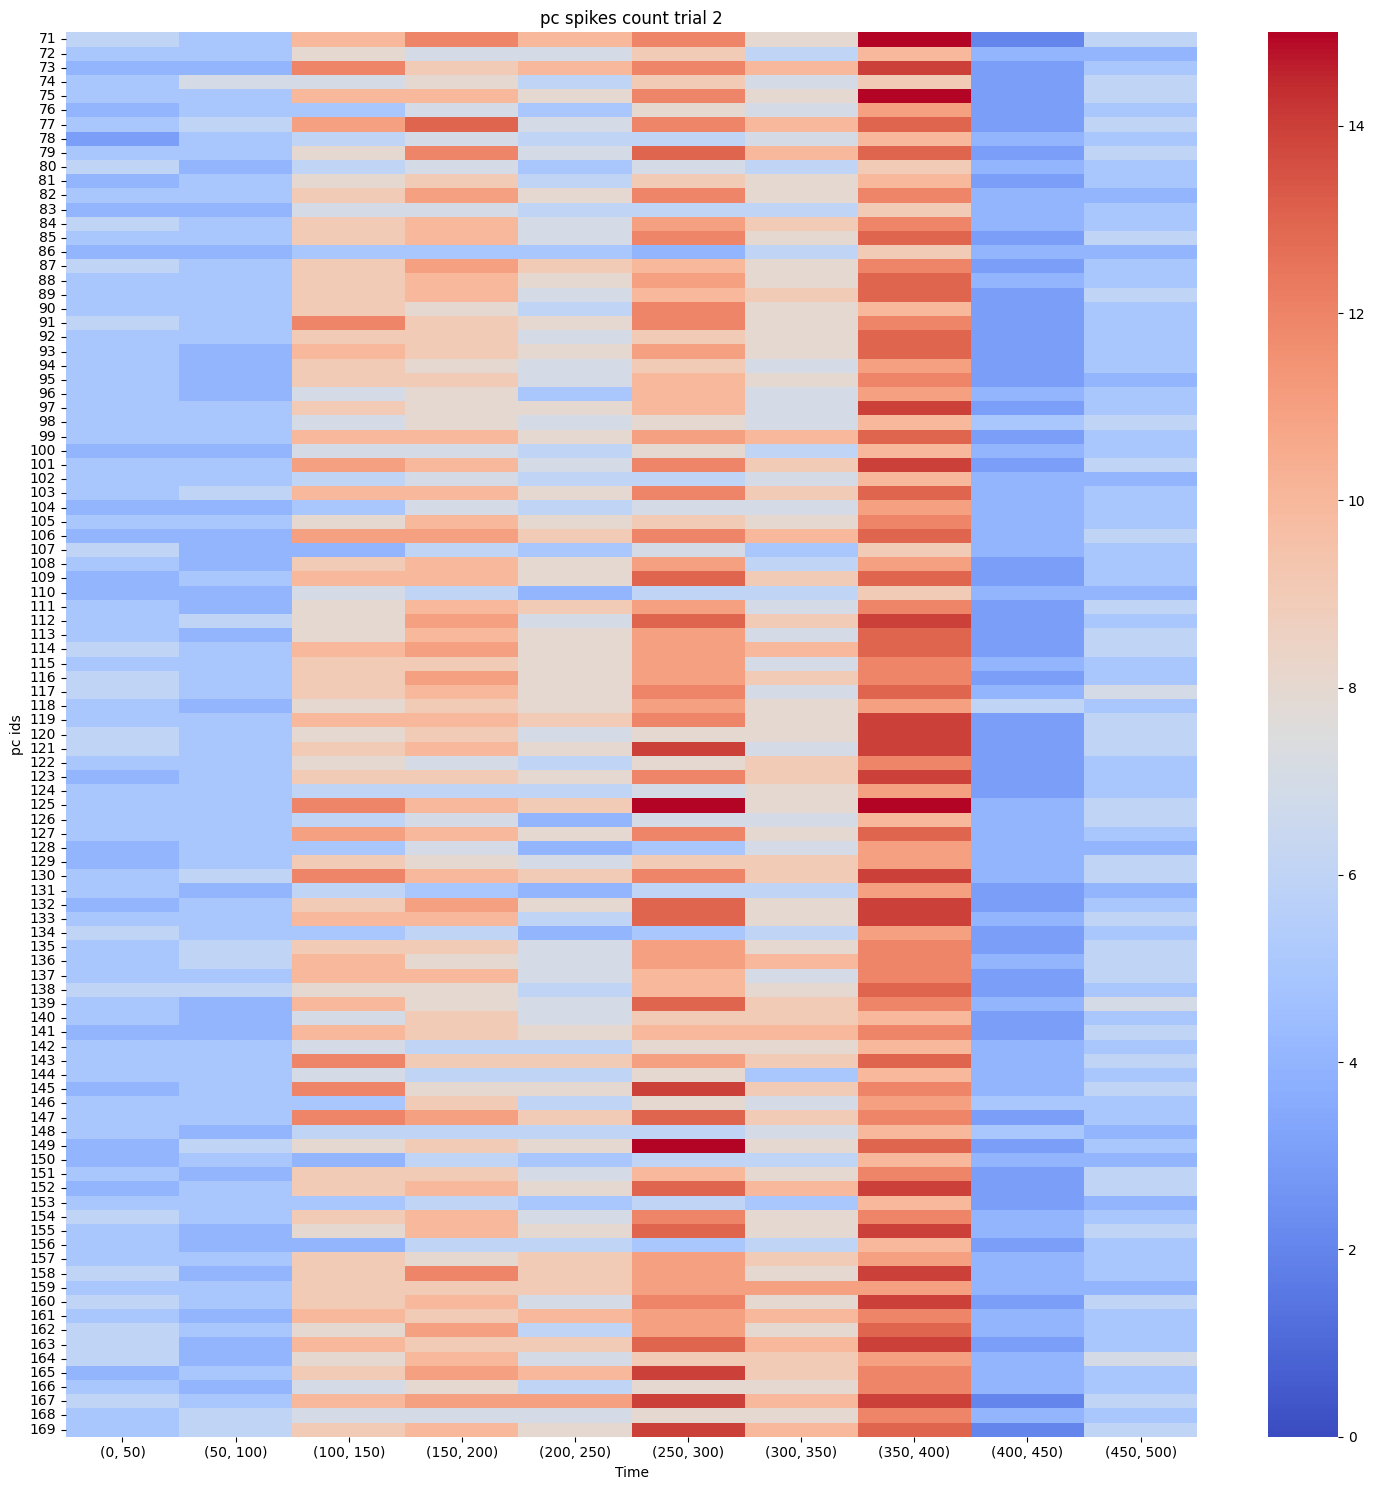

In [7]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_2, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmin = 0,
            vmax = 15
            )
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('pc spikes count trial 2')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_2')


/tmp/ipykernel_3039473/768584616.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


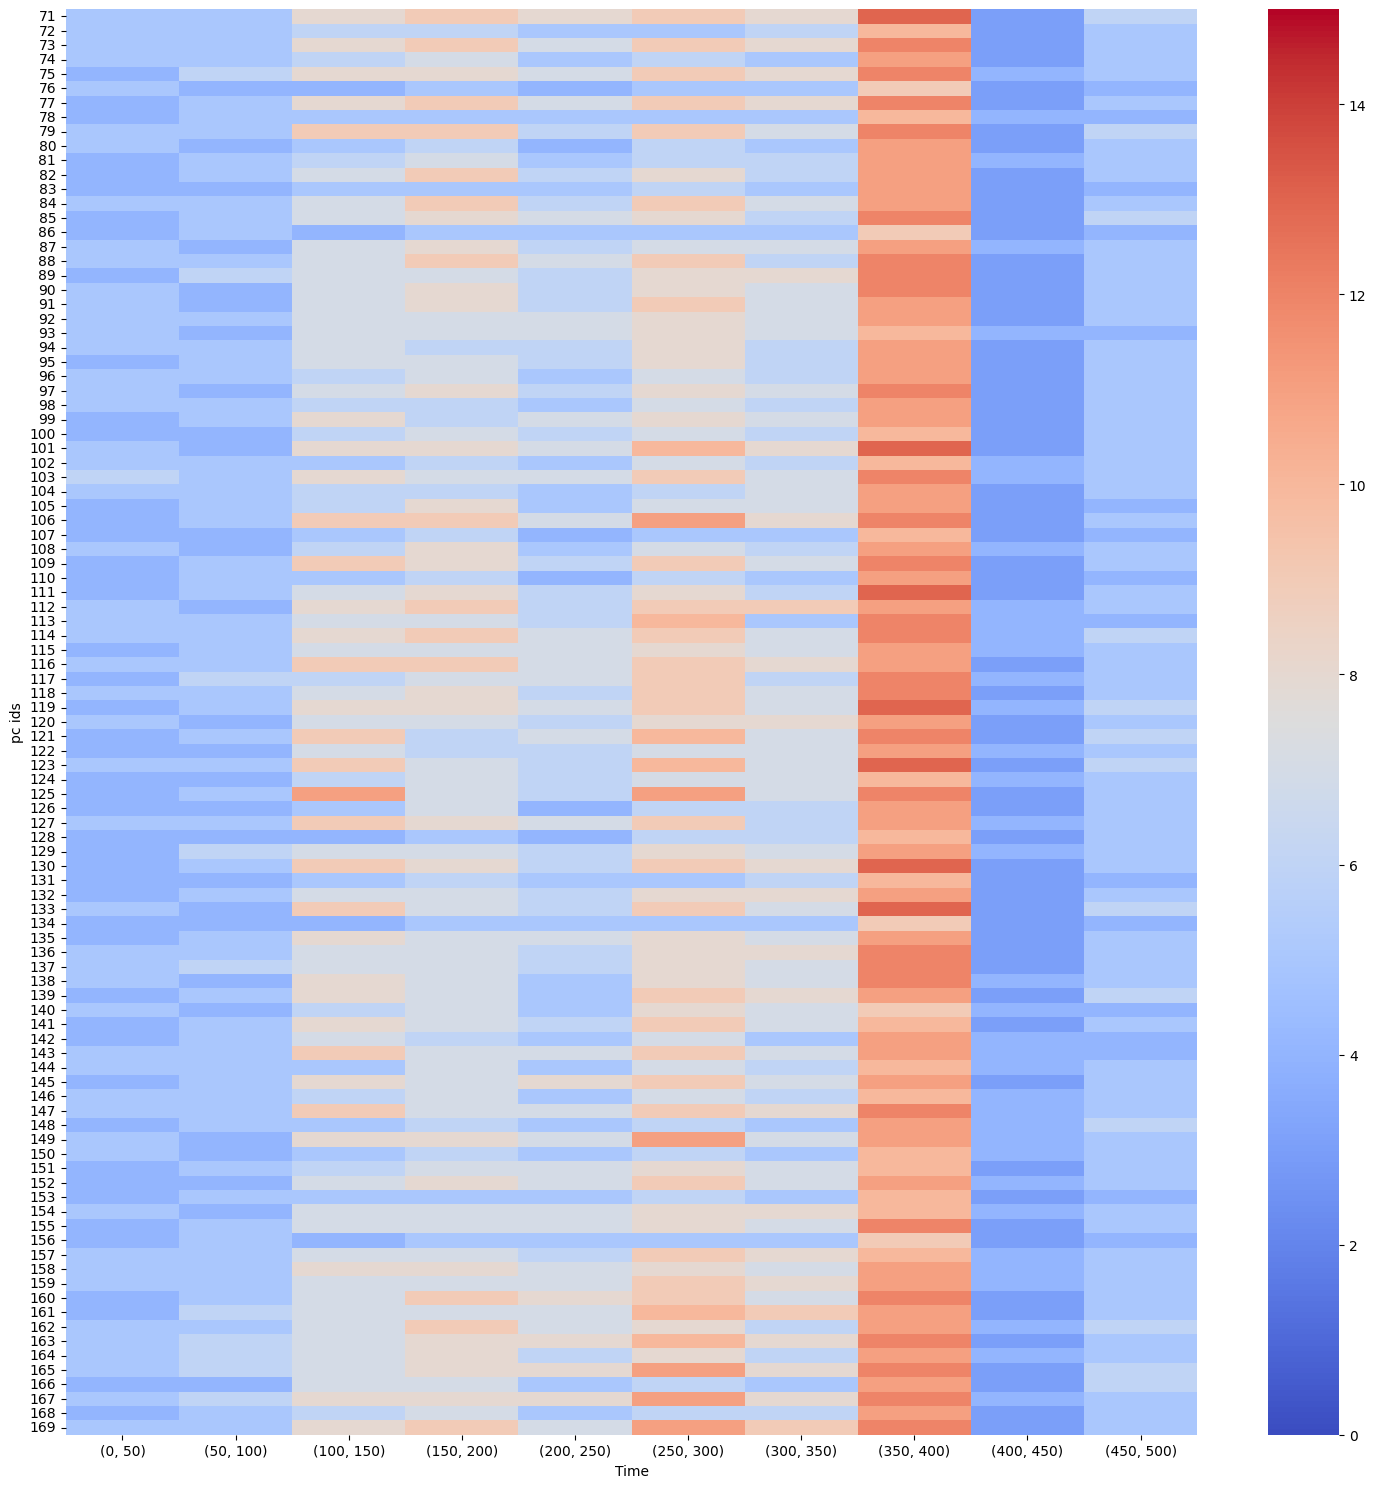

In [8]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_30, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmin = 0,
            vmax = 15
            )
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_30')

/tmp/ipykernel_3039473/1369467128.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


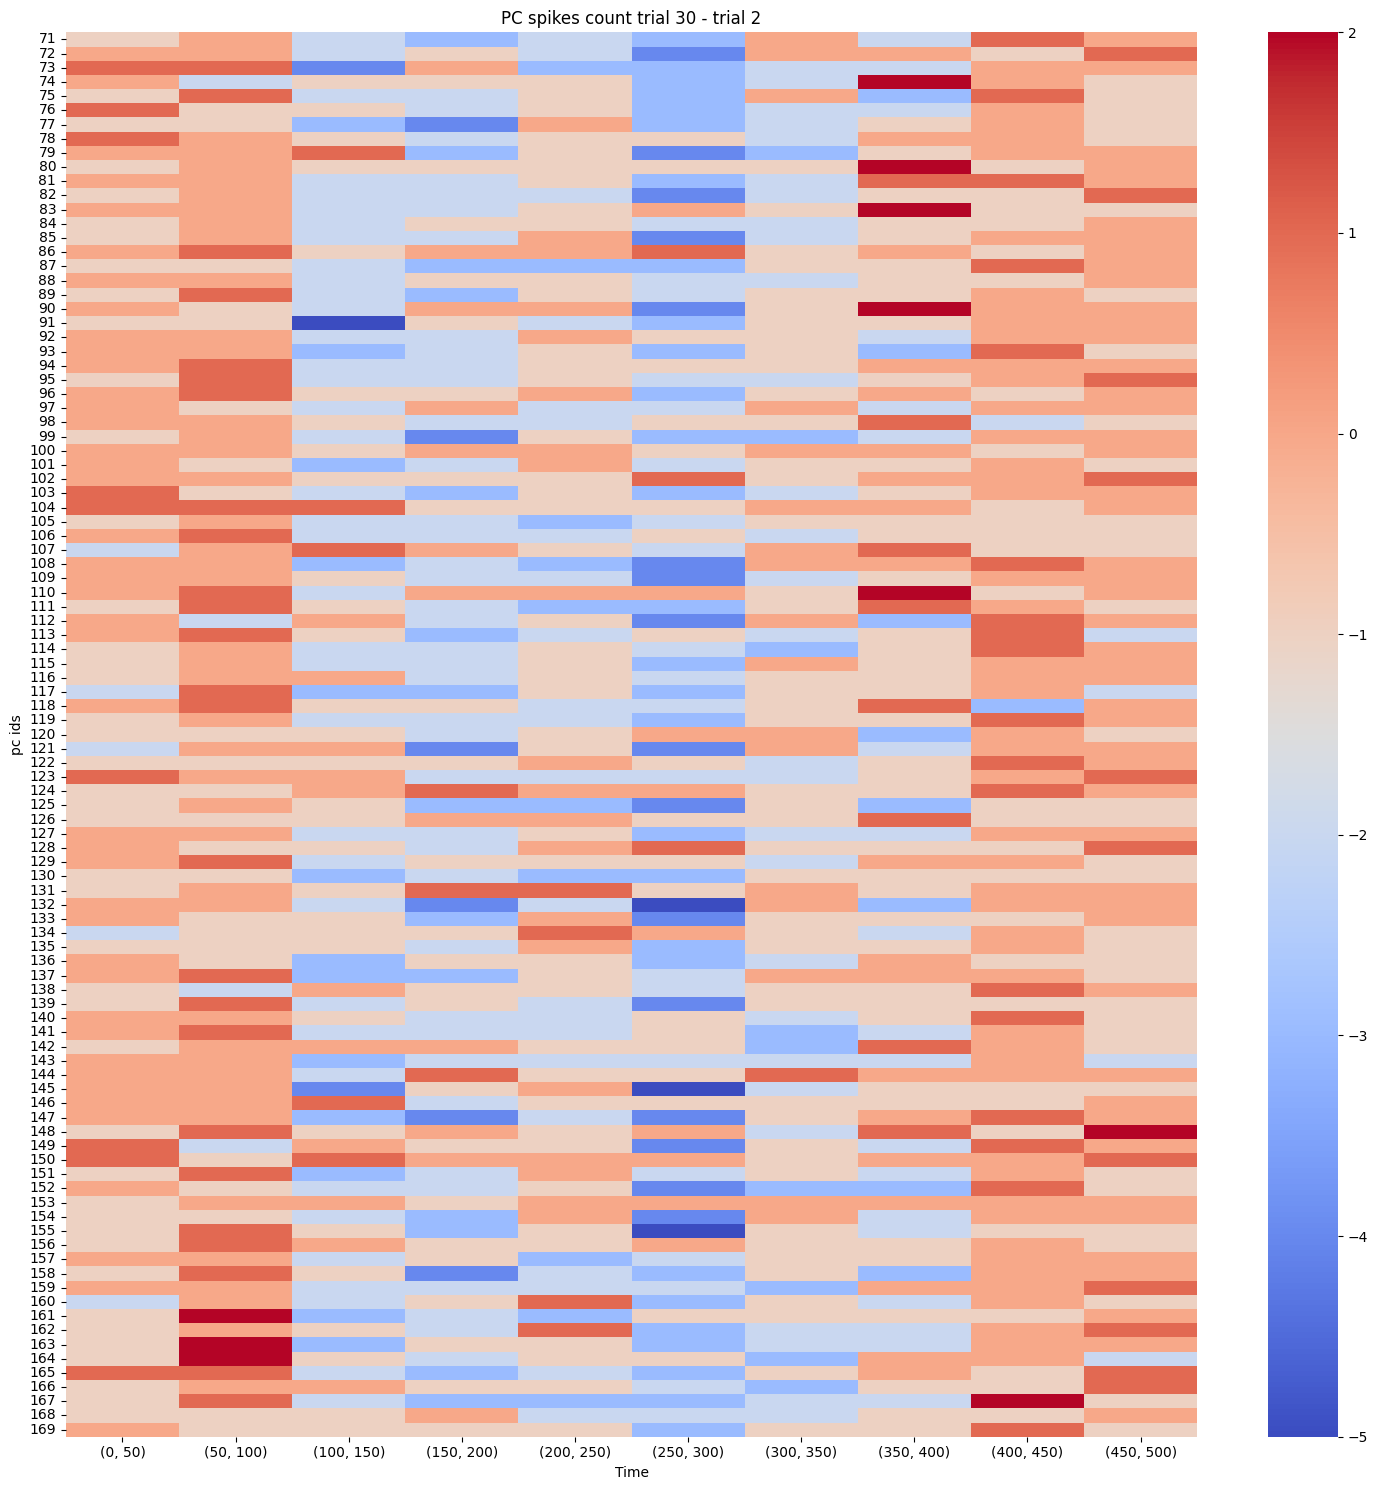

In [9]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_diff, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmin = -5,
            vmax = 2
            )
plt.xticks(rotation = 0)
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('PC spikes count trial 30 - trial 2')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_diff')

In [29]:
pc_change = np.zeros((len(pc_ids),3))
for i in range(3):
    pc_change[:,i] = pc_spikes_matrix_trial_diff[:,5]-pc_spikes_matrix_trial_diff[:,2+i]

pc_change_median = pc_spikes_matrix_trial_diff[:,5] - np.median(pc_spikes_matrix_trial_diff[:,2:5], axis =1)
pc_change_cr_bs = pc_spikes_matrix_trial_diff[:,5] - pc_spikes_matrix_trial_diff[:,3]

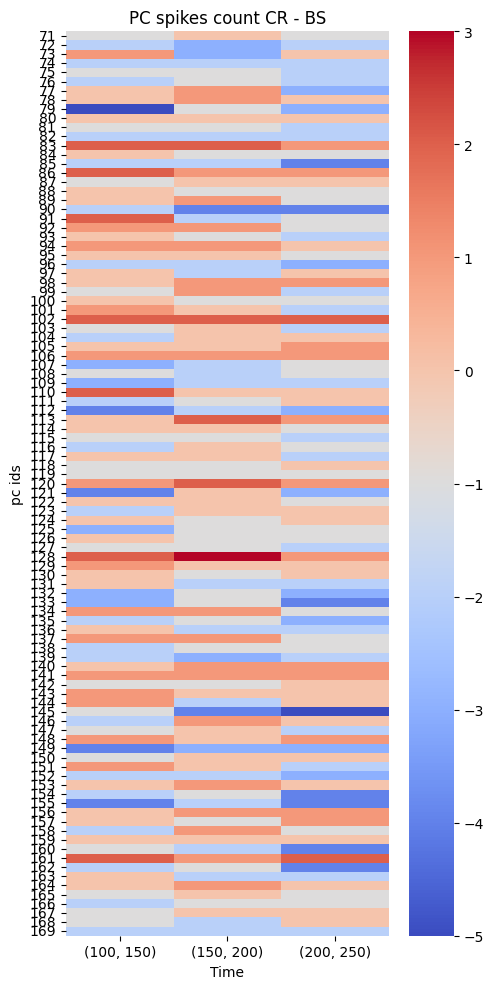

In [11]:
plt.figure(figsize=(5,10))
sns.heatmap(pc_change, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(100,250,time_bin)], 
            yticklabels=pc_ids,
            vmin = -5,
            vmax = 3
            )
plt.xticks(rotation = 0)
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('PC spikes count CR - BS')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_diff')

In [12]:
# heatmaps of number of spikes for every PC
result_path = rooth_path+"test/thr_60/"
pc_spikes_matrix_trial_2_60 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
pc_spikes_matrix_trial_30_60 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
pc_spikes_matrix_trial_diff_60 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
trial_len = between_start
for k in range(0,n_sim):
    file_path = result_path+f'sim_{k+1}/'
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0].astype(int)

    intervals = [(500,1000), (14500,15000)]
    for i,interval in enumerate(intervals):
        for j,t_interval in enumerate(range(interval[0],interval[1],time_bin)):
            start = t_interval
            end = t_interval+time_bin
            mask = (times >= start) & (times <= end)
            filtered_ids = ID_cell[mask]


            for id in np.unique(filtered_ids):
                count_spikes = len(np.where(filtered_ids==id)[0])
                ind_pc_id = np.where(pc_ids == id)[0]
                if i == 0:
                    pc_spikes_matrix_trial_2_60[ind_pc_id,j,k] = count_spikes
                else:
                    pc_spikes_matrix_trial_30_60[ind_pc_id,j,k] = count_spikes

pc_spikes_matrix_trial_30_60 = np.median(pc_spikes_matrix_trial_30_60,axis = 2)
pc_spikes_matrix_trial_2_60 = np.median(pc_spikes_matrix_trial_2_60,axis = 2)
pc_spikes_matrix_trial_diff_60 = pc_spikes_matrix_trial_30_60 - pc_spikes_matrix_trial_2_60

/tmp/ipykernel_3039473/3419147920.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


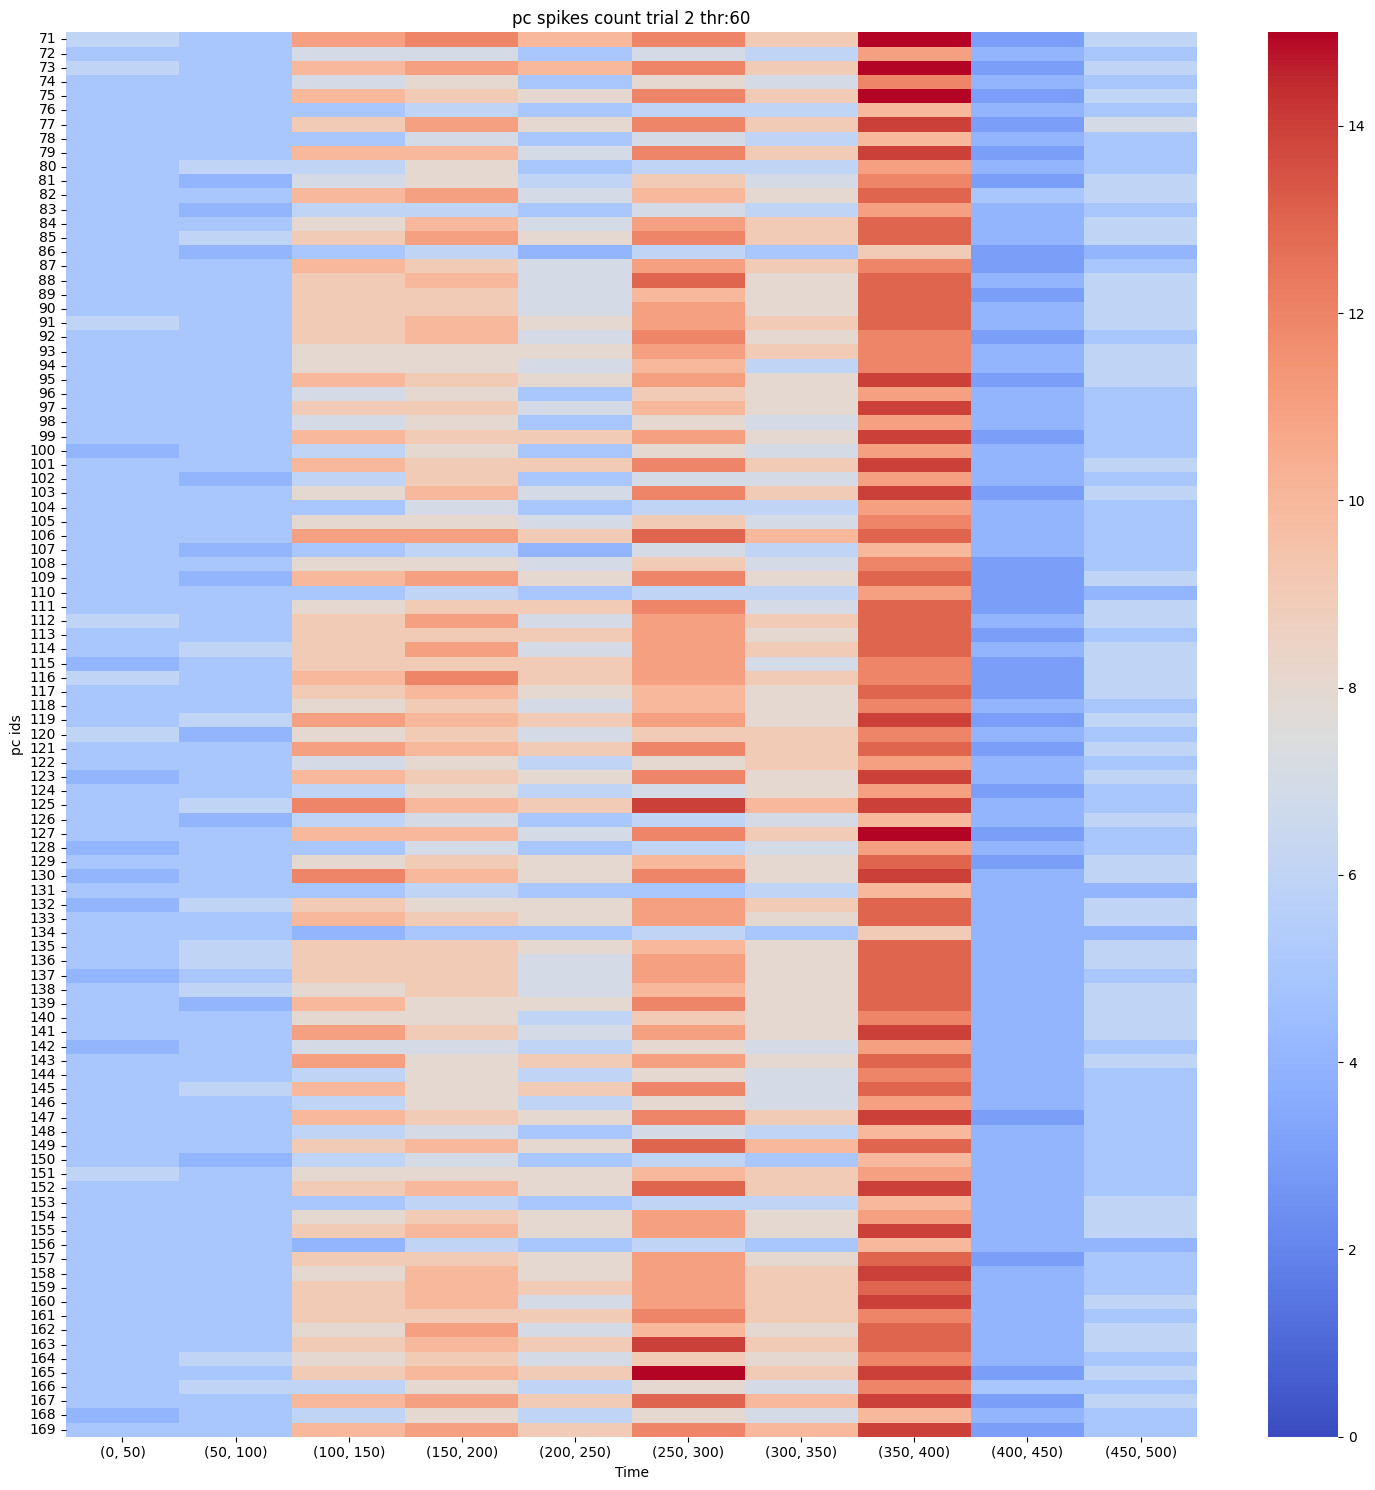

In [13]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_2_60, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmin = 0,
            vmax = 15
            )
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('pc spikes count trial 2 thr:60')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_2_thr60')

/tmp/ipykernel_3039473/3095577329.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


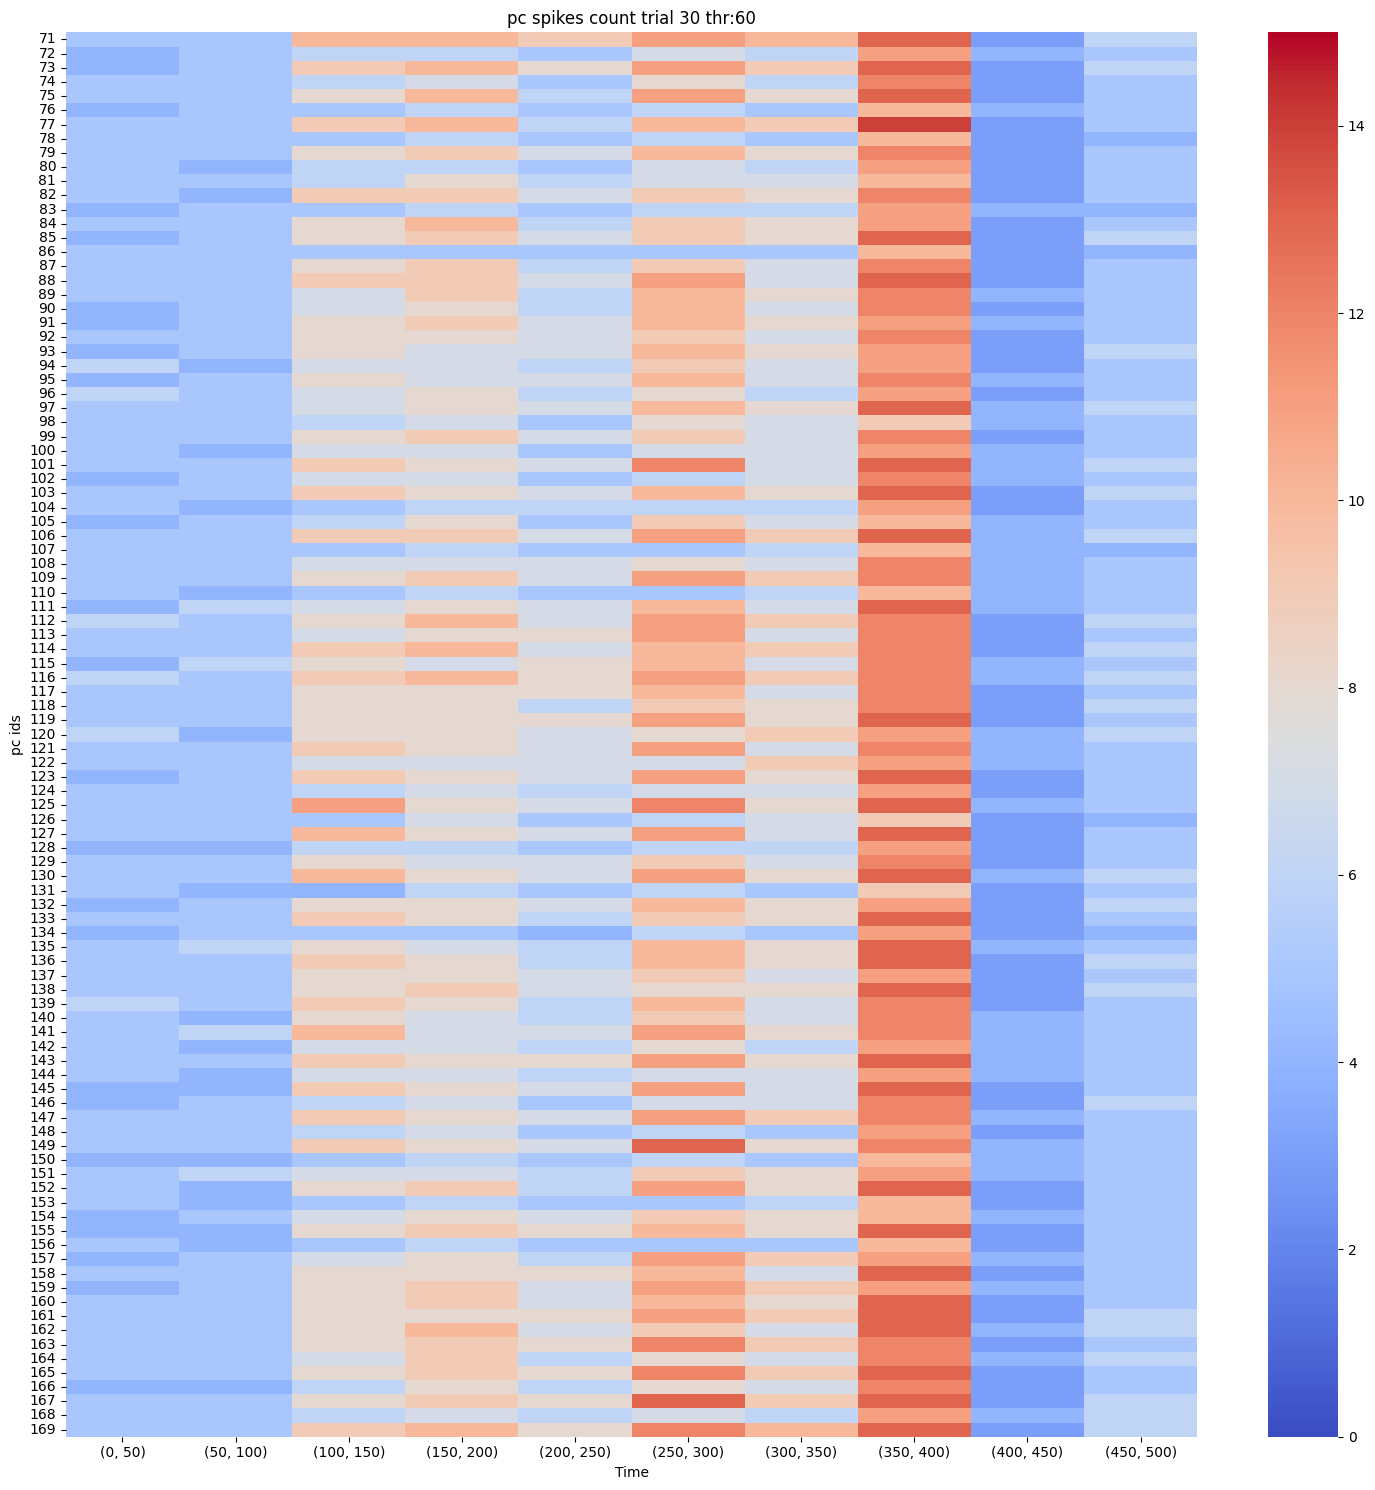

In [14]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_30_60, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmin = 0,
            vmax = 15
            )
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('pc spikes count trial 30 thr:60')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_30_thr_60')

/tmp/ipykernel_3039473/2601428579.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


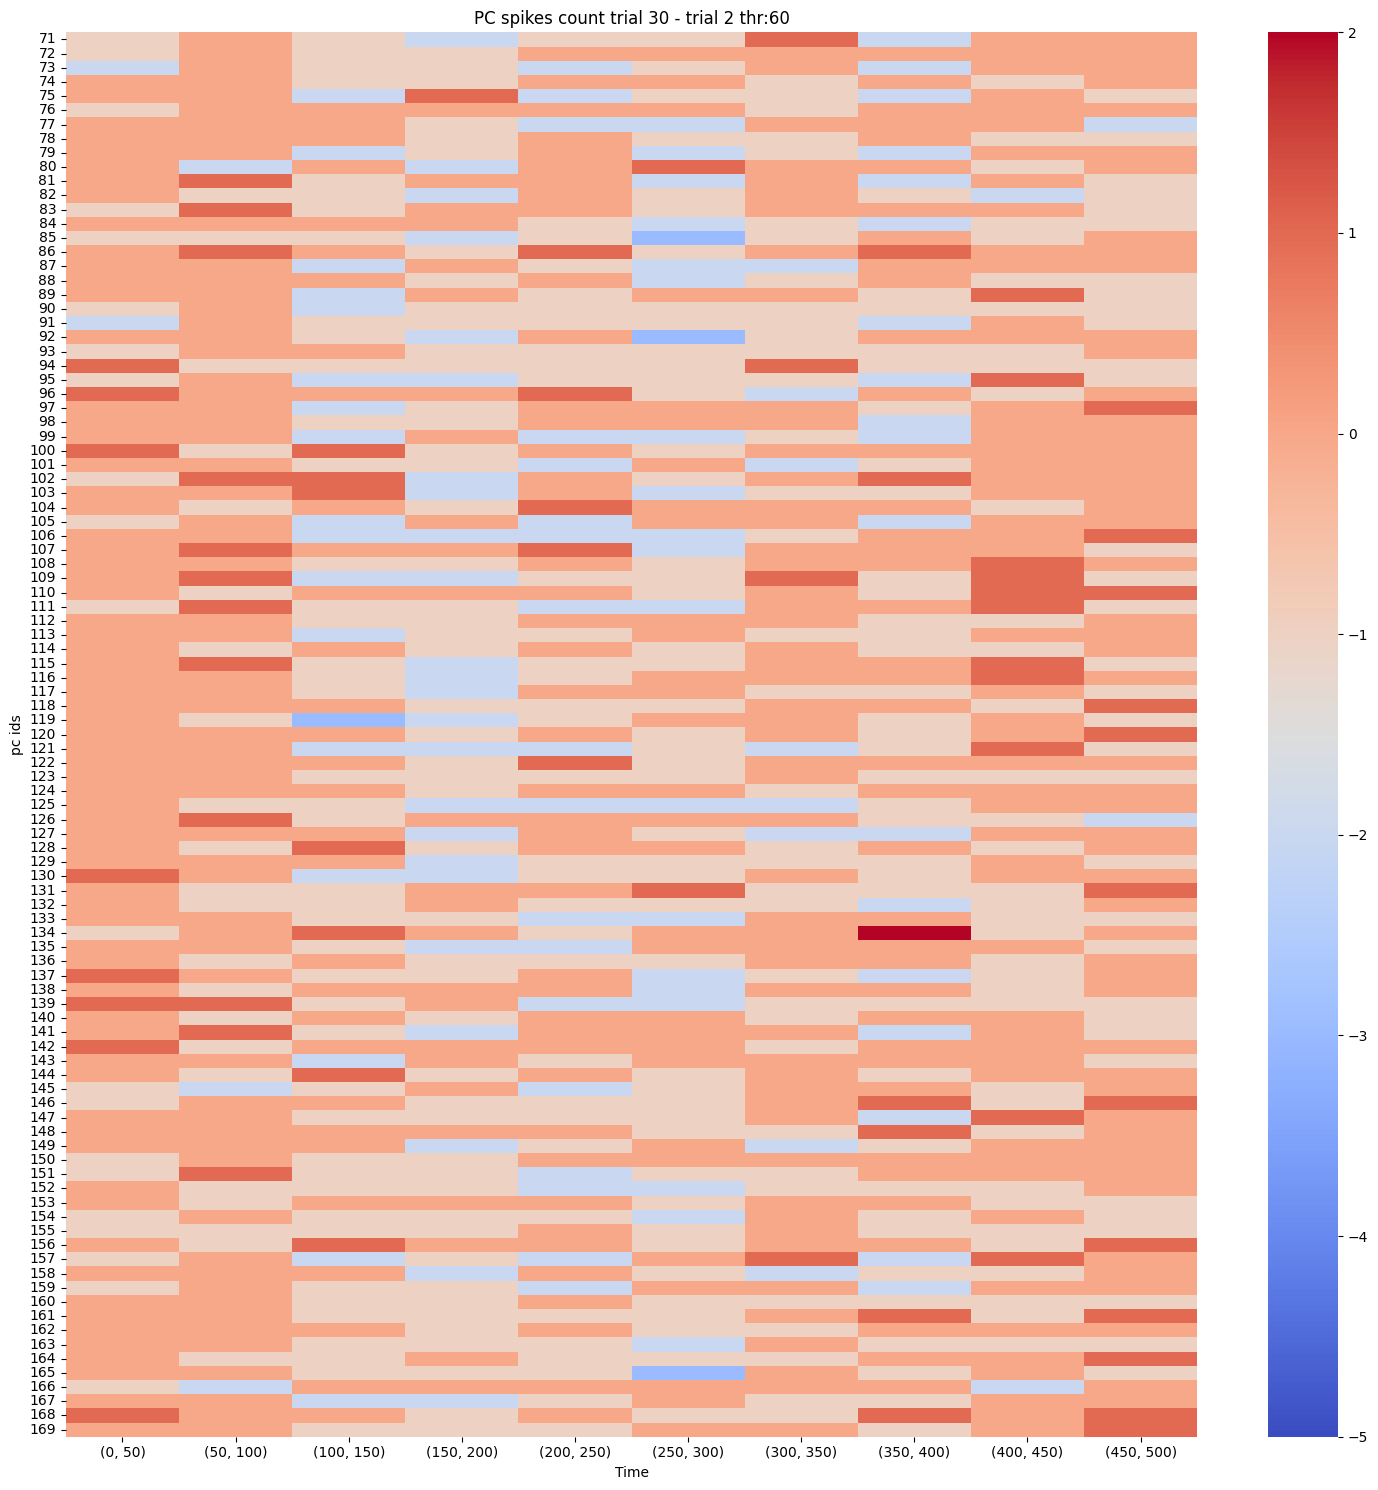

In [15]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_diff_60, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmax = 2,
            vmin = -5
            )
plt.xticks(rotation = 0)
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('PC spikes count trial 30 - trial 2 thr:60' )
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_diff_thr60')

In [31]:
pc_change_60 = np.zeros((len(pc_ids),3))
for i in range(3):
    pc_change_60[:,i] = pc_spikes_matrix_trial_diff_60[:,5]-pc_spikes_matrix_trial_diff_60[:,2+i]

pc_change_median_60 = pc_spikes_matrix_trial_diff_60[:,5] - np.median(pc_spikes_matrix_trial_diff_60[:,2:5], axis =1)
pc_change_cr_bs_60 = pc_spikes_matrix_trial_diff_60[:,5] - pc_spikes_matrix_trial_diff_60[:,3]

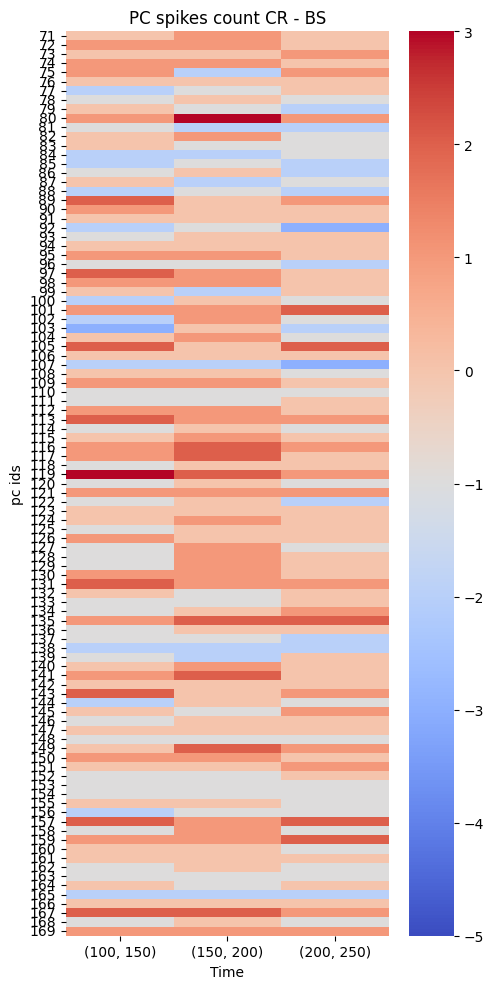

In [17]:
plt.figure(figsize=(5,10))
sns.heatmap(pc_change_60, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(100,250,time_bin)], 
            yticklabels=pc_ids,
            vmin = -5,
            vmax = 3
            )
plt.xticks(rotation = 0)
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('PC spikes count CR - BS')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_diff')

In [18]:
# heatmaps of number of spikes for every PC
result_path = rooth_path+"test/thr_100/"
pc_spikes_matrix_trial_2_100 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
pc_spikes_matrix_trial_30_100 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
pc_spikes_matrix_trial_diff_100 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
trial_len = between_start
for k in range(0,n_sim):
    file_path = result_path+f'sim_{k+1}/'
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0].astype(int)

    intervals = [(500,1000), (14500,15000)]
    for i,interval in enumerate(intervals):
        for j,t_interval in enumerate(range(interval[0],interval[1],time_bin)):
            start = t_interval
            end = t_interval+time_bin
            mask = (times >= start) & (times <= end)
            filtered_ids = ID_cell[mask]


            for id in np.unique(filtered_ids):
                count_spikes = len(np.where(filtered_ids==id)[0])
                ind_pc_id = np.where(pc_ids == id)[0]
                if i == 0:
                    pc_spikes_matrix_trial_2_100[ind_pc_id,j,k] = count_spikes
                else:
                    pc_spikes_matrix_trial_30_100[ind_pc_id,j,k] = count_spikes

pc_spikes_matrix_trial_30_100 = np.median(pc_spikes_matrix_trial_30_100,axis = 2)
pc_spikes_matrix_trial_2_100 = np.median(pc_spikes_matrix_trial_2_100,axis = 2)
pc_spikes_matrix_trial_diff_100 = pc_spikes_matrix_trial_30_100 - pc_spikes_matrix_trial_2_100

/tmp/ipykernel_3039473/344713318.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


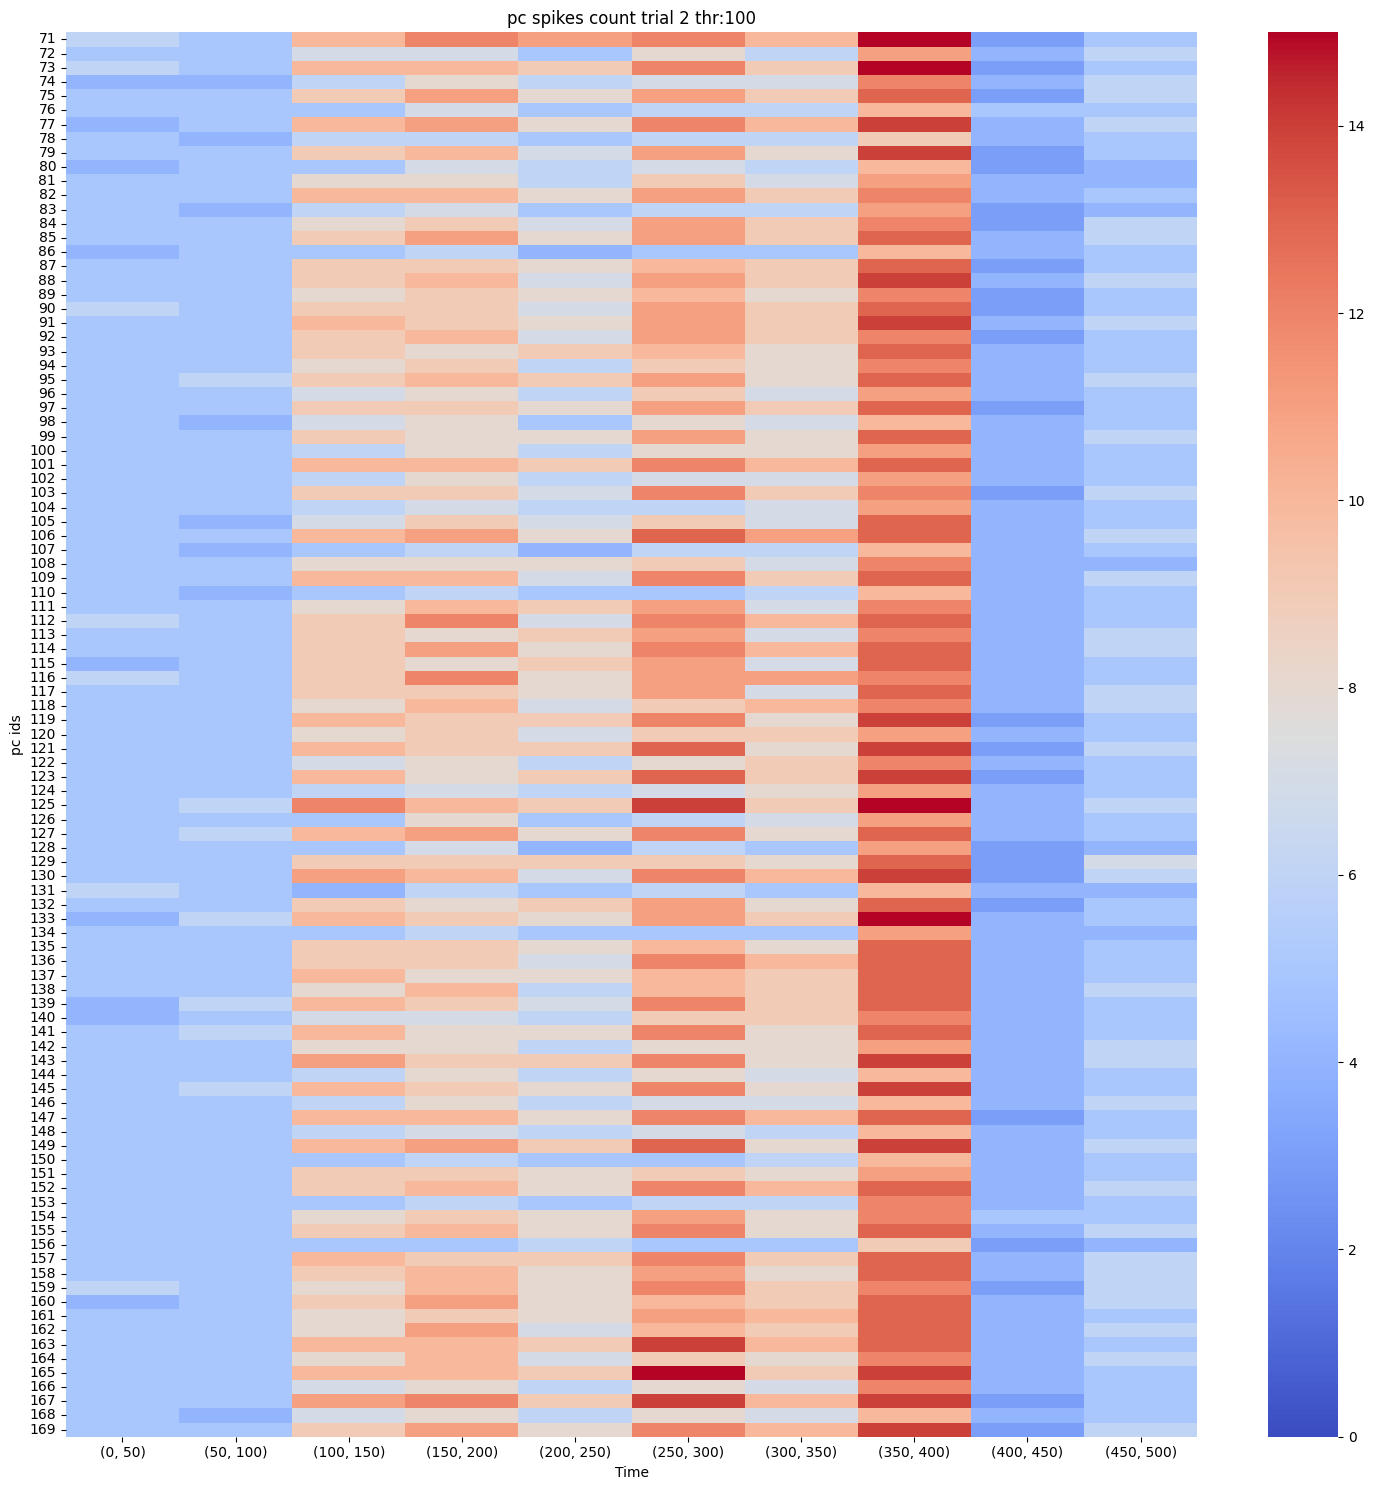

In [19]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_2_100, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmin = 0,
            vmax = 15
            )
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('pc spikes count trial 2 thr:100')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_2_thr100')

/tmp/ipykernel_3039473/3090656545.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


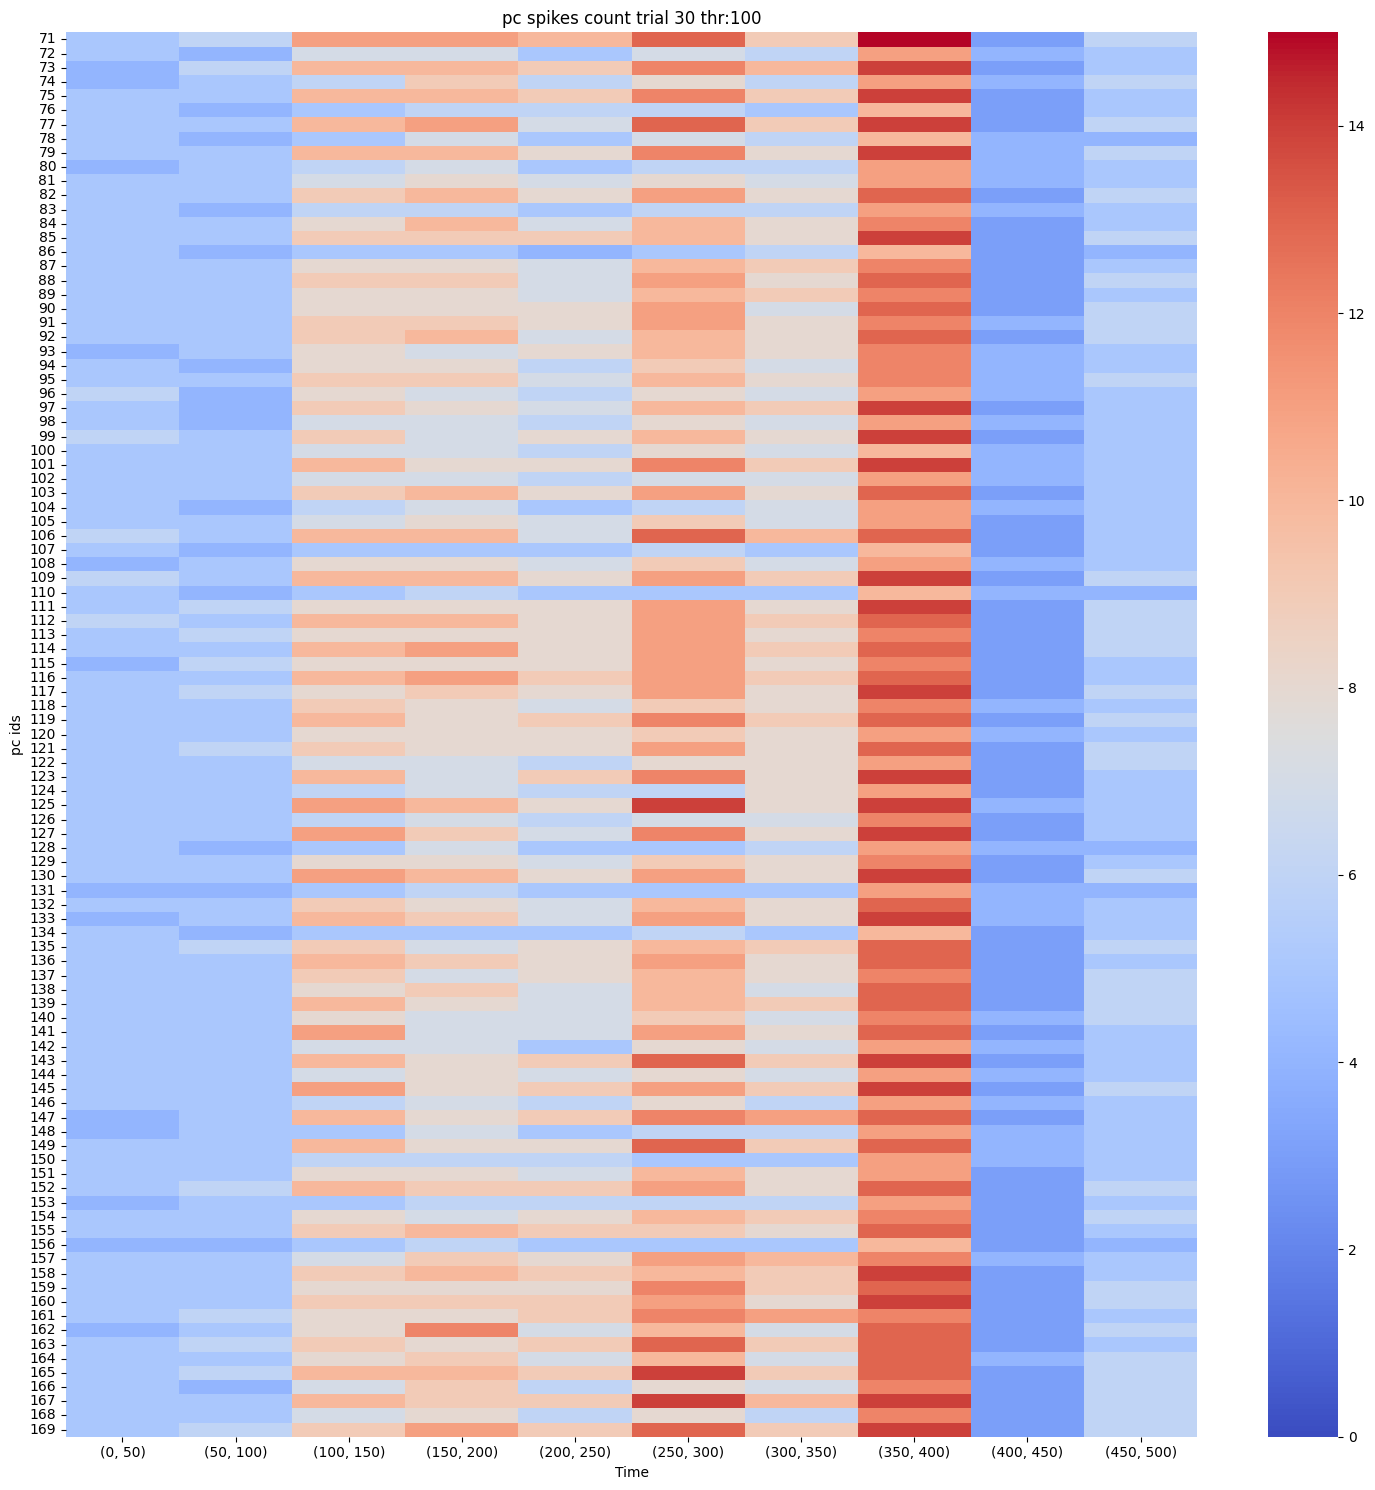

In [20]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_30_100, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmin = 0,
            vmax = 15
            )
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('pc spikes count trial 30 thr:100')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_2_thr100')

/tmp/ipykernel_3039473/904552688.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


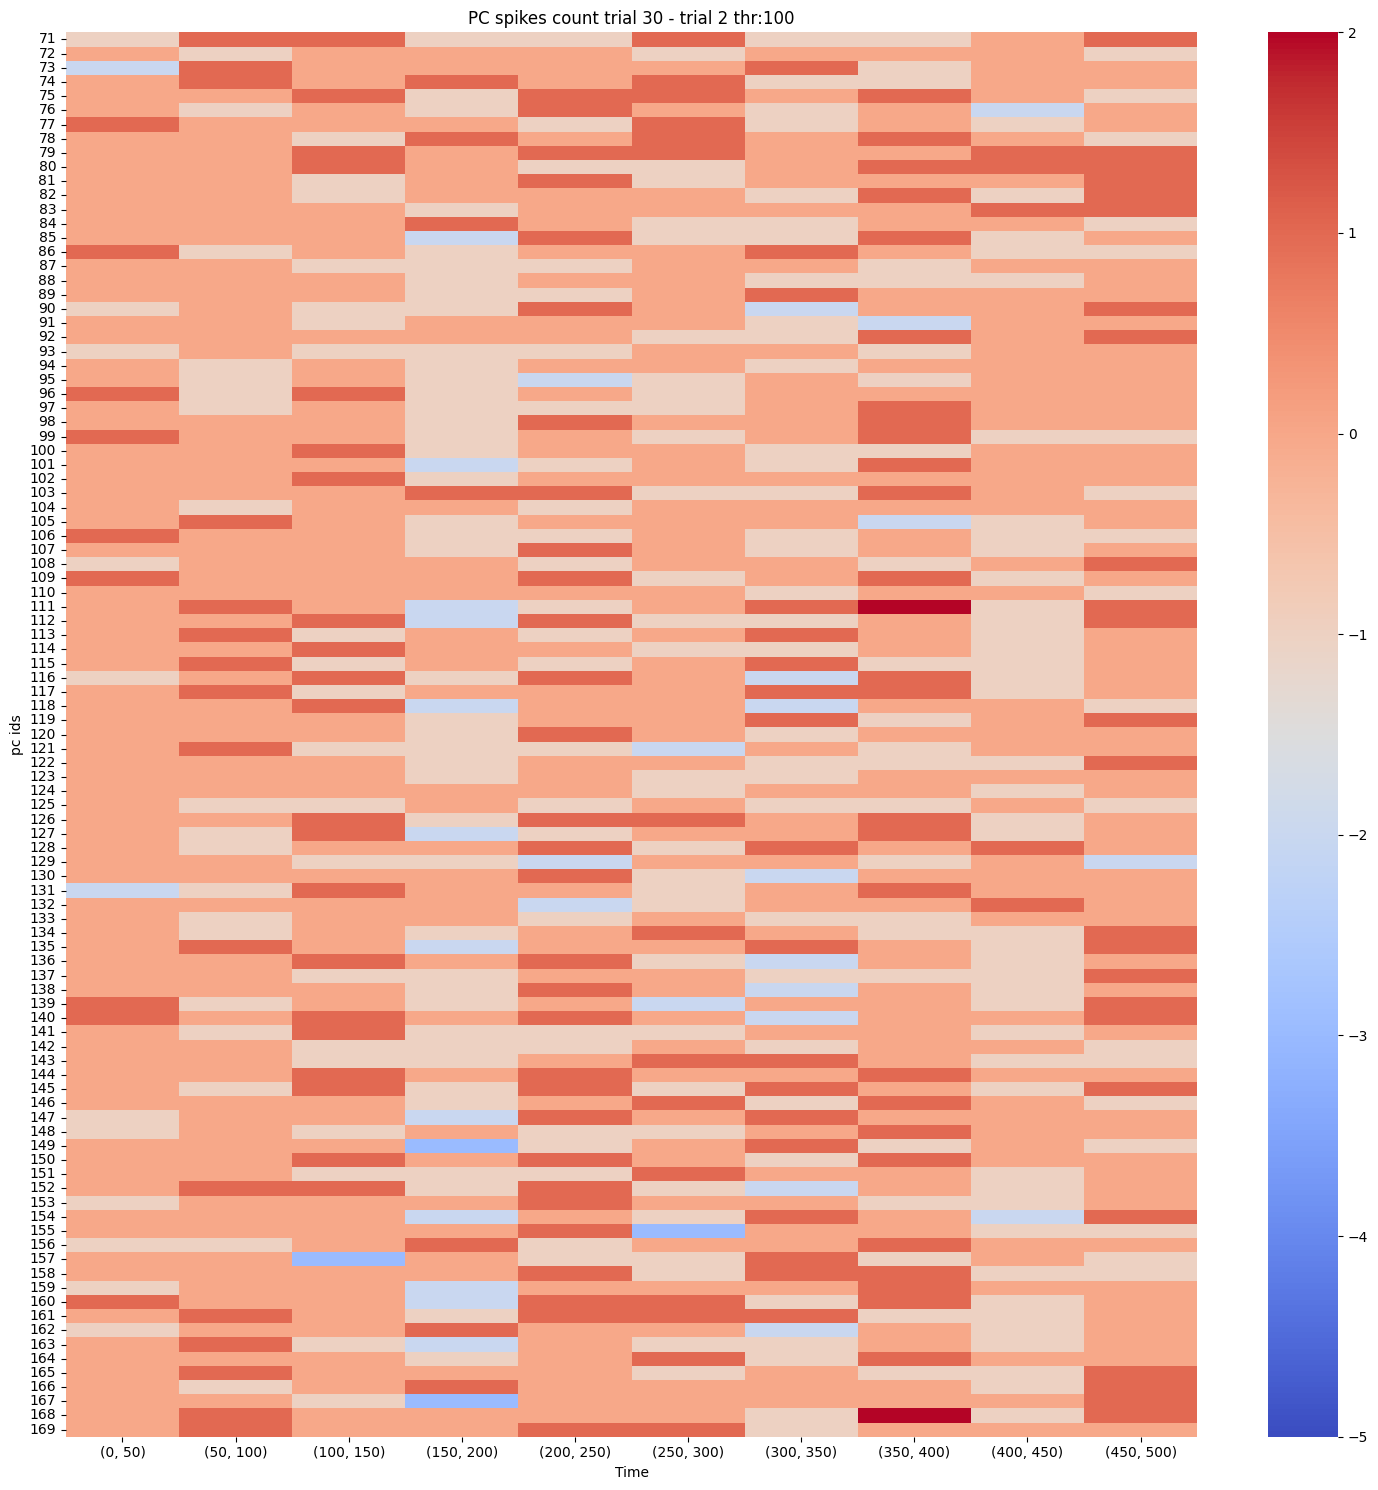

In [21]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(15,15))
sns.heatmap(pc_spikes_matrix_trial_diff_100, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(0,500,time_bin)], 
            yticklabels=pc_ids,
            vmin = -5,
            vmax = 2
            )
plt.xticks(rotation = 0)
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('PC spikes count trial 30 - trial 2 thr:100' )
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_diff_thr100')

In [32]:
pc_change_100 = np.zeros((len(pc_ids),3))
for i in range(3):
    pc_change_100[:,i] = pc_spikes_matrix_trial_diff_100[:,5]-pc_spikes_matrix_trial_diff_100[:,2+i]

pc_change_median_100 = pc_spikes_matrix_trial_diff_100[:,5] - np.median(pc_spikes_matrix_trial_diff_100[:,2:5], axis =1)
pc_change_cr_bs_100 = pc_spikes_matrix_trial_diff_100[:,5] - pc_spikes_matrix_trial_diff_100[:,3]

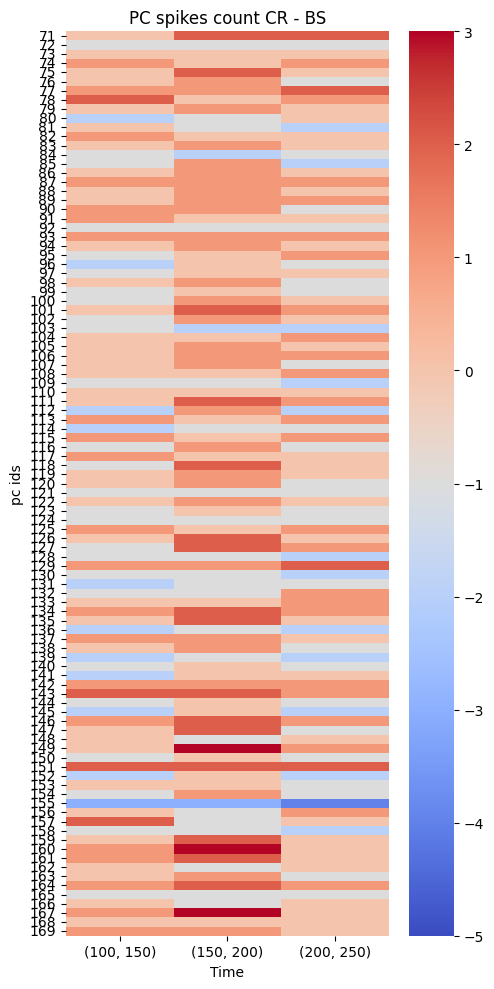

In [23]:
plt.figure(figsize=(5,10))
sns.heatmap(pc_change_100, 
            cmap = cmap, 
            xticklabels=[(i,i+time_bin)for i in range(100,250,time_bin)], 
            yticklabels=pc_ids,
            vmin = -5,
            vmax = 3
            )
plt.xticks(rotation = 0)
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('PC spikes count CR - BS')
plt.tight_layout()
#plt.savefig('pc_spikes_count_trial_diff')

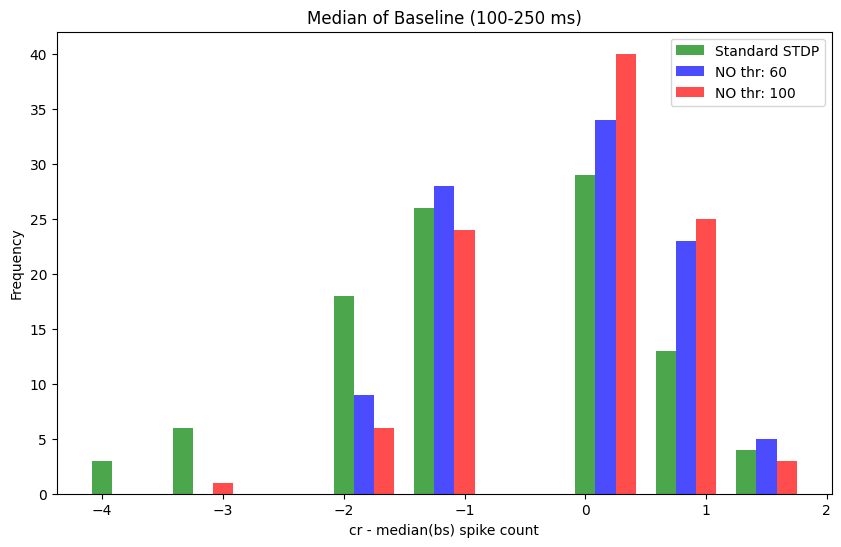

In [36]:
bins = np.linspace(-4, 2, 10)  # Adjust range and number of bins as needed

# Compute histogram values
hist1, _ = np.histogram(pc_change_median, bins=bins)
hist2, _ = np.histogram(pc_change_median_60, bins=bins)
hist3, _ = np.histogram(pc_change_median_100, bins=bins)

# Define the width of each bar
bar_width = (bins[1] - bins[0]) / 4  # Divide bin width to create space for 3 bars

# Define bar positions
positions1 = bins[:-1]  # First bar at original positions
positions2 = positions1 + bar_width  # Second bar shifted right
positions3 = positions1 + 2 * bar_width  # Third bar shifted further

# Plot each histogram as bars
plt.figure(figsize=(10, 6))
plt.bar(positions1, hist1, width=bar_width, alpha=0.7, label='Standard STDP', color='g')
plt.bar(positions2, hist2, width=bar_width, alpha=0.7, label='NO thr: 60', color='b')
plt.bar(positions3, hist3, width=bar_width, alpha=0.7, label='NO thr: 100', color='r')

# Add labels and legend
plt.xlabel('cr - median(bs) spike count')
plt.ylabel('Frequency')
plt.title('Median of Baseline (100-250 ms)')
plt.legend()
plt.show()

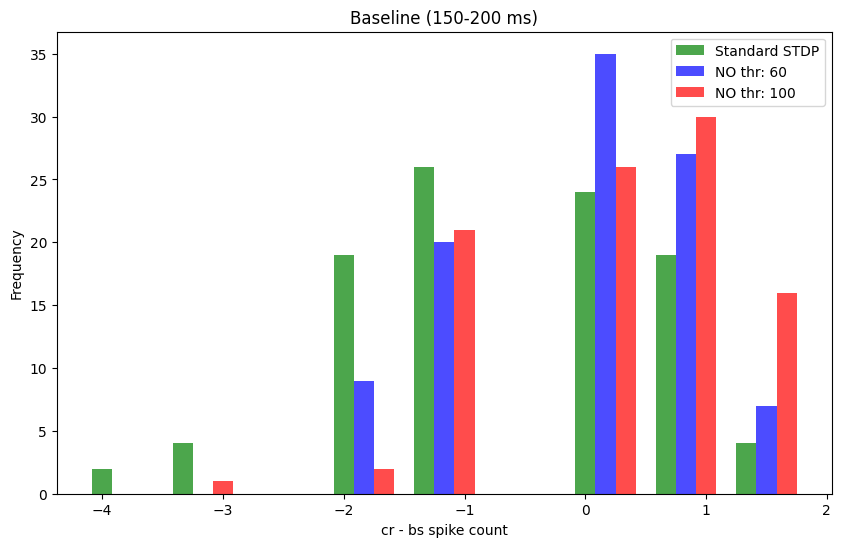

In [35]:
bins = np.linspace(-4, 2, 10)  # Adjust range and number of bins as needed

# Compute histogram values
hist1, _ = np.histogram(pc_change_cr_bs, bins=bins)
hist2, _ = np.histogram(pc_change_cr_bs_60, bins=bins)
hist3, _ = np.histogram(pc_change_cr_bs_100, bins=bins)

# Define the width of each bar
bar_width = (bins[1] - bins[0]) / 4  # Divide bin width to create space for 3 bars

# Define bar positions
positions1 = bins[:-1]  # First bar at original positions
positions2 = positions1 + bar_width  # Second bar shifted right
positions3 = positions1 + 2 * bar_width  # Third bar shifted further

# Plot each histogram as bars
plt.figure(figsize=(10, 6))
plt.bar(positions1, hist1, width=bar_width, alpha=0.7, label='Standard STDP', color='g')
plt.bar(positions2, hist2, width=bar_width, alpha=0.7, label='NO thr: 60', color='b')
plt.bar(positions3, hist3, width=bar_width, alpha=0.7, label='NO thr: 100', color='r')

# Add labels and legend
plt.xlabel('cr - bs spike count')
plt.ylabel('Frequency')
plt.title('Baseline (150-200 ms)')
plt.legend()
plt.show()